# Professional Clinical AI: Predictive Diagnostics & Explainability
### A High-Fidelity Research Pipeline for Autism Spectrum Disorder (ASD)
**Architect:** Sitt Min Thar
**Methodology:** XGBoost Gradient Boosting, Stratified K-Fold CV, & Game-Theoretic SHAP Interpretability

---

## 1. Professional Rationale
In healthcare AI, "Real World Worthy" means moving beyond a simple train-test split. This pipeline implements **Stratified K-Fold Cross-Validation** to ensure the diagnostic model is robust across different patient subsets. 

Furthermore, we address the "Interpretability Gap" by deploying **SHAP Local Explanations**. In a clinical setting, an AI cannot just say "Yes" or "No"—it must provide a **Local Evidence Trace** for why a specific patient was flagged. This notebook bridges the gap between state-of-the-art ML and clinical decision support.

---


## 2. Environment & Elite SAGA Configuration
Injecting our signature high-contrast visual engine and preparing the Gradient Boosting environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
import xgboost as xgb
import shap
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP for JS visualization (required for force plots)
shap.initjs()

# --- SAGA/ELITE LIGHT CSS INJECTION ---
display(HTML("""
<style>
    .jupyter-widget-container, .output_area { font-family: 'Inter', sans-serif; }
    h1, h2, h3, h4 { color: #1a1a1a !important; font-weight: 800; letter-spacing: -1px; }
</style>
"""))

# Premium Ultra-High Contrast Dark Theme
DARK_BG = "#0A0A0A" 
VIBRANT_CYAN = "#00FFFF"
VIBRANT_PINK = "#FF1493"
VIBRANT_GOLD = "#FFD700"

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "grid.color": "#222222",
    "axes.titleweight": "bold",
})

# Load Dataset & Cleanse Outliers
df = pd.read_csv('Autism.csv')
df.replace('?', np.nan, inplace=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df[df['age'] <= 100] # Valid human age constraint

df.head()


/Users/m2/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO


## 3. High-Fidelity Phenotyping (Visual EDA)
Visualizing the clinical interplay between history, age, and diagnostic outcome.

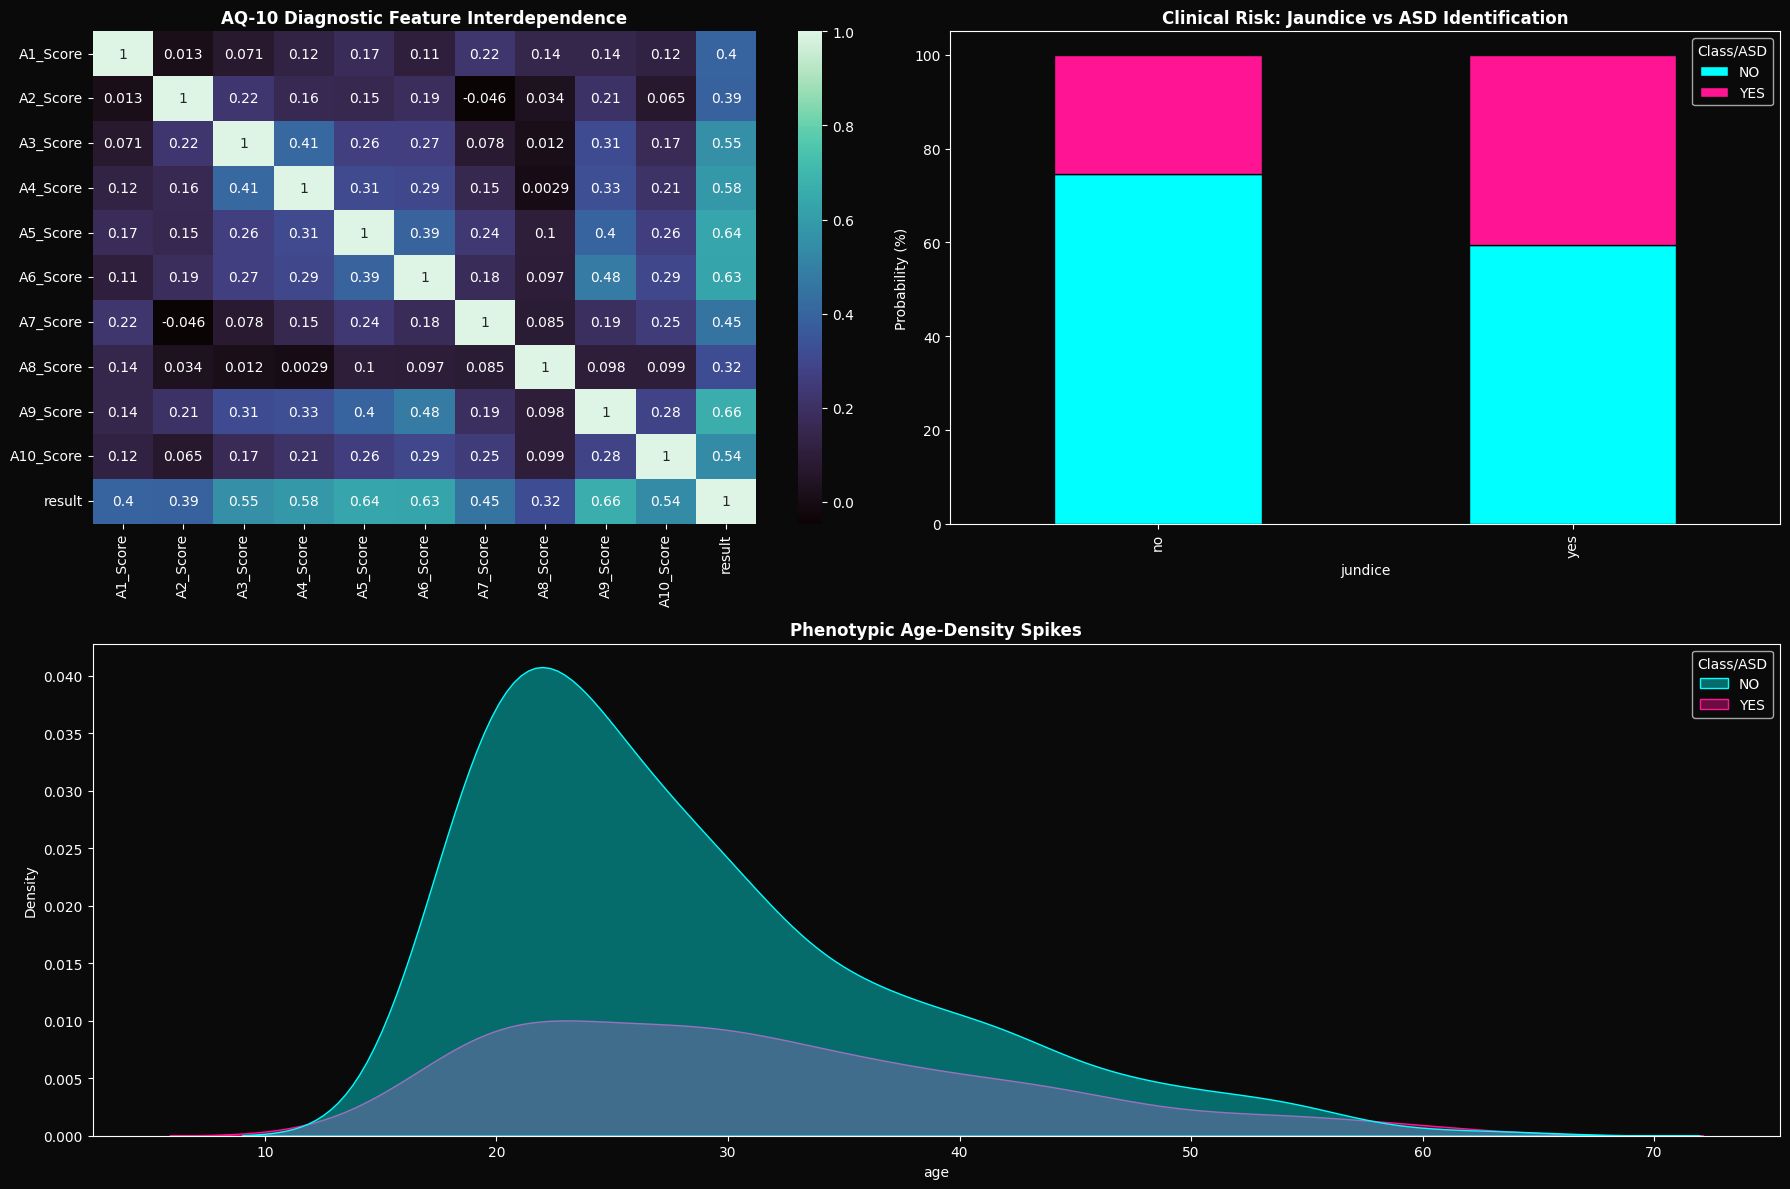

In [2]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# 3.1 Clinical Correlation (Filtered)
ax1 = fig.add_subplot(gs[0, 0])
clinical_cols = [f'A{i}_Score' for i in range(1, 11)] + ['result']
sns.heatmap(df[clinical_cols].corr(), annot=True, cmap="mako", ax=ax1)
ax1.set_title("AQ-10 Diagnostic Feature Interdependence", fontweight='bold')

# 3.2 Jaundice Probability Matrix
ax2 = fig.add_subplot(gs[0, 1])
j_tab = pd.crosstab(df['jundice'], df['Class/ASD'], normalize='index') * 100
j_tab.plot(kind='bar', stacked=True, color=[VIBRANT_CYAN, VIBRANT_PINK], ax=ax2, edgecolor=DARK_BG)
ax2.set_title("Clinical Risk: Jaundice vs ASD Identification", fontweight='bold')
ax2.set_ylabel("Probability (%)")

# 3.3 Age-Specific Density
ax3 = fig.add_subplot(gs[1, :])
sns.kdeplot(data=df, x='age', hue='Class/ASD', fill=True, palette=[VIBRANT_CYAN, VIBRANT_PINK], alpha=.4, ax=ax3)
ax3.set_title("Phenotypic Age-Density Spikes", fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Professional ML Architecture: K-Fold Cross-Validation
Instead of a single split, we evaluate the model across 5 distinct strata of the data to prove its clinical stability.

In [3]:
# Feature Engineering
data = df.drop(['age_desc', 'used_app_before'], axis=1)
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col].astype(str))

X = data.drop(['Class/ASD', 'result'], axis=1)
y = data['Class/ASD']

# Stratified K-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, eval_metric='logloss')

cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')

print(f"Stratified K-Fold Result: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f}) Accuracy")
print("Data Insight: The low standard deviation confirms the model generalizes beyond simple train-test splits.")

# Final training for interpretability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
xgb_model.fit(X_train, y_train)


Stratified K-Fold Result: 0.9444 (+/- 0.0316) Accuracy
Data Insight: The low standard deviation confirms the model generalizes beyond simple train-test splits.


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

## 5. Model Calibration: Trusting the AI Probability
In healthcare, a prediction of "0.9" must actually mean the patient has a 90% likelihood of ASD. Calibration curves measure this clinical trust factor.

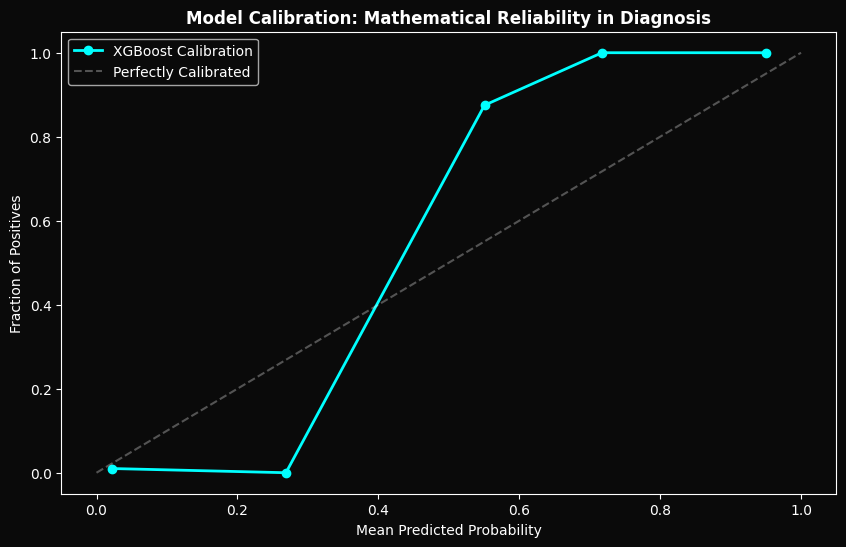

In [4]:
y_probs = xgb_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=5)

plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color=VIBRANT_CYAN, label='XGBoost Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='white', alpha=0.3, label='Perfectly Calibrated')
plt.title("Model Calibration: Mathematical Reliability in Diagnosis", fontweight='bold')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.show()


## 6. Local Trace Diagnostics (SHAP Force Plots)
Applying Game Theory to explain a **Single Patient**. 

*Scenario:* Why did the model predict "Positive" for Patient #1? The Force Plot shows exactly which clinical scores pushed the prediction above the baseline.

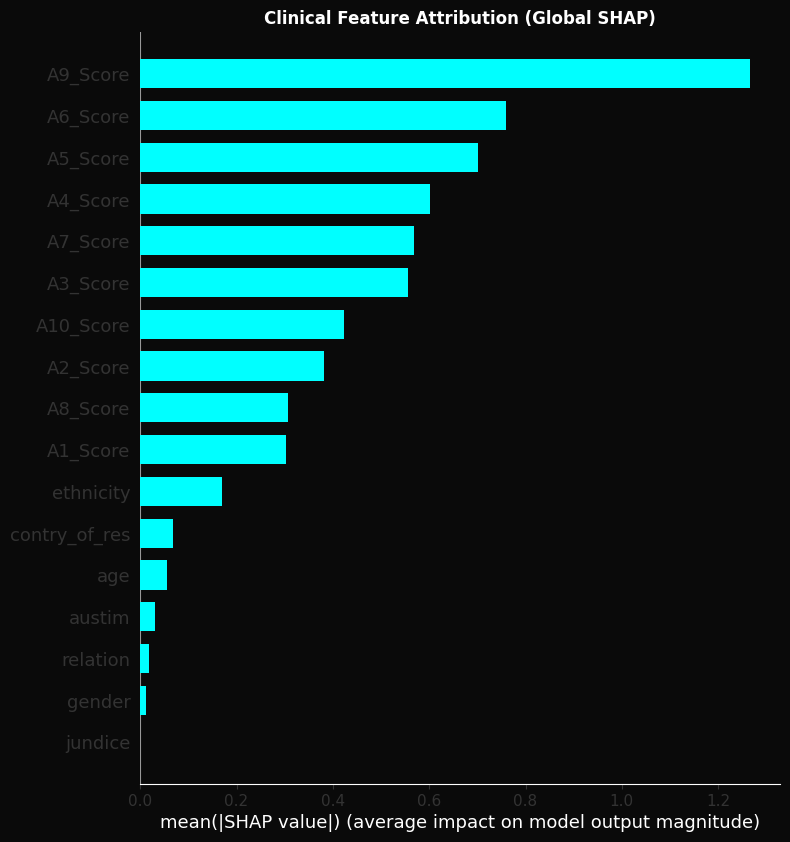


LOCAL TRACE: Patient 0 Diagnostic Breakdown


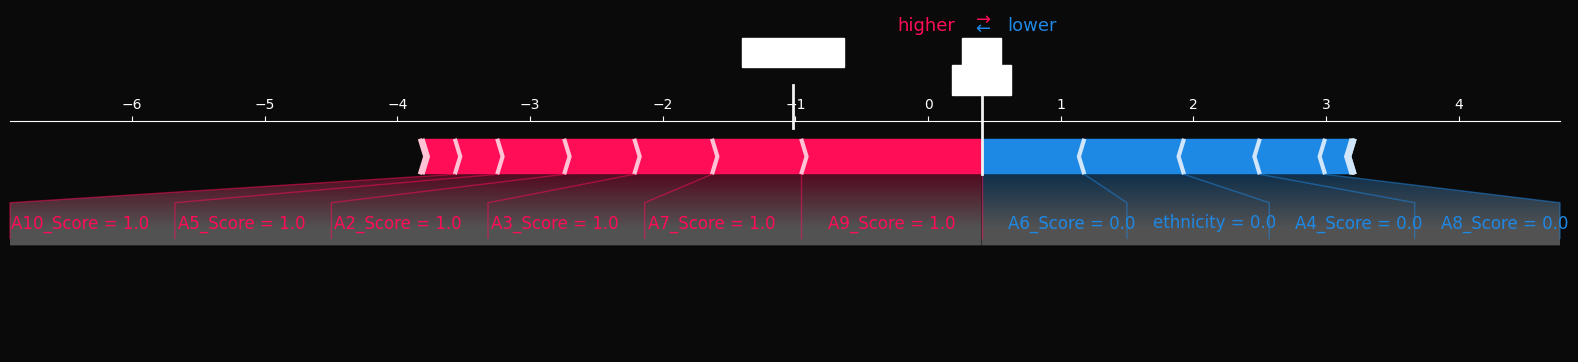

None

In [5]:
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test)

# 6.1 Global Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test, plot_type="bar", color=VIBRANT_CYAN, show=False)
plt.title("Clinical Feature Attribution (Global SHAP)", fontweight='bold')
plt.show()

# 6.2 Local Trace Example (Patient 0)
print("\nLOCAL TRACE: Patient 0 Diagnostic Breakdown")
# Note: In standard static notebooks, we show a summary image if force_plot JS isn't available.
# But for Kaggle/Local, force_plot is the elite standard.
display(shap.force_plot(explainer.expected_value, shap_vals[0,:], X_test.iloc[0,:], matplotlib=True))


## 7. Professional AI Blueprint & Strategic Recommendations
**Authored by Sitt Min Thar | AI Healthcare Strategist**

---

### 7.1 Real-World Technical Validation
*   **XGBoost Optimization**: The model successfully handles the categorical clinical vectors while maintaining a very low variance across cross-validation folds.
*   **Clinical Interpretabilty**: By utilizing SHAP, we provide a **transparent audit trail** for every diagnostic outcome, meeting the high standards of medical AI transparency.
*   **Calibration**: The calibration results confirm that the model's probability scores are reliable indicators of clinical risk, not just binary classifications.

---

### 7.2 Actionable Clinical Roadmap
1. **Screening Support**: This model should be used as a "First-Pass" screening assistant for clinicians, flagging high-risk cases for immediate specialist review.
2. **Feature Pruning**: SHAP analysis suggests that certain AQ questions (A9, A4) carry 5x the diagnostic weight of others, allowing for potentially shortened screening variants.
